# Explorative Data Aanalysis of the $CH_4$ plumes 

This notebook explores the methane plumes downloaded as the EMIT-L2B product.

In [2]:
from datetime import datetime, timedelta
from pathlib import Path
import earthaccess

import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio as rio
from shapely.geometry import Point, Polygon, shape, box

In [3]:
WORKING_DIR = Path("C:/Users/Julia/OneDrive/Dokumenty/WORK/PhD/IBM/CH4/")

In [4]:
gdf = gpd.read_file(WORKING_DIR / "data/emit_ch4_plumes_metadata.gpkg")

In [5]:
gdf.head()

,name,latitude (centroid),longitude (centroid),area_km2,bounds,width_km,height_km,startDate,endDate,max_ch4_concentration,concentration_uncertainty,geometry
0,20220810T064957_000485,31.123154,35.206945,6.269775,"(35.1922411, 31.1113516, 35.2226061, 31.135752)",2.896241,2.705311,2022-08-10T06:49:57Z,2022-08-10T06:49:57Z,2895.0,553.0,"POLYGON ((35.20309 31.13575, 35.19549 31.13521..."
1,20220810T065021_000486,31.905596,36.229274,2.265073,"(36.2213984, 31.8975887, 36.2382076, 31.9133135)",1.589982,1.743647,2022-08-10T06:49:57Z,2022-08-10T06:49:57Z,1331.0,343.0,"POLYGON ((36.22574 31.91331, 36.2214 31.9106, ..."
2,20220810T065132_000487,35.299036,40.464131,3.403105,"(40.4421363, 35.2919643, 40.4844305, 35.3082313)",3.846811,1.804760,2022-08-10T06:49:57Z,2022-08-10T06:49:57Z,3401.0,526.0,"POLYGON ((40.45135 35.30823, 40.44214 35.30769..."
3,20220810T065132_000496,35.279094,40.508176,8.382147,"(40.4865994, 35.2664794, 40.5310625, 35.293591)",4.045078,3.007916,2022-08-10T06:49:57Z,2022-08-10T06:49:57Z,1364.0,308.0,"POLYGON ((40.49256 35.29359, 40.48823 35.29088..."
4,20220811T042630_000490,22.340710,56.404999,8.274078,"(56.3929904, 22.3163401, 56.4173908, 22.3629721)",2.513594,5.163789,2022-08-11T04:26:30Z,2022-08-11T04:26:30Z,1312.0,383.0,"POLYGON ((56.40329 22.36297, 56.39733 22.36189..."


## Checking the area of plumes distribution

In [5]:
print(f"max width = {gdf["width_km"].max()} \nmax height = {gdf["height_km"].max()}")
print(f"min width = {gdf["width_km"].min()} \nmin height = {gdf["height_km"].min()}")
print(f"mean width = {gdf["width_km"].mean()} \nmean height = {gdf["height_km"].mean()}")
print(f"median width = {gdf["width_km"].median()} \nmedian height = {gdf["height_km"].median()}")
print(f"min area = {gdf["area_km2"].min()} \nmax area = {gdf["area_km2"].max()} \nmean area = {gdf["area_km2"].mean()} \nmedian area = {gdf["area_km2"].median()}")

max width = 70.18868423988263 
max height = 69.56130176294003
min width = 0.35848364894087054 
min height = 0.3006051294168854
mean width = 4.361090966294492 
mean height = 4.125987993074411
median width = 2.4855036745052947 
median height = 2.4668634011897046
min area = 0.112647509383291 
max area = 522.1092912657741 
mean area = 15.852319200044791 
median area = 3.467065109104112


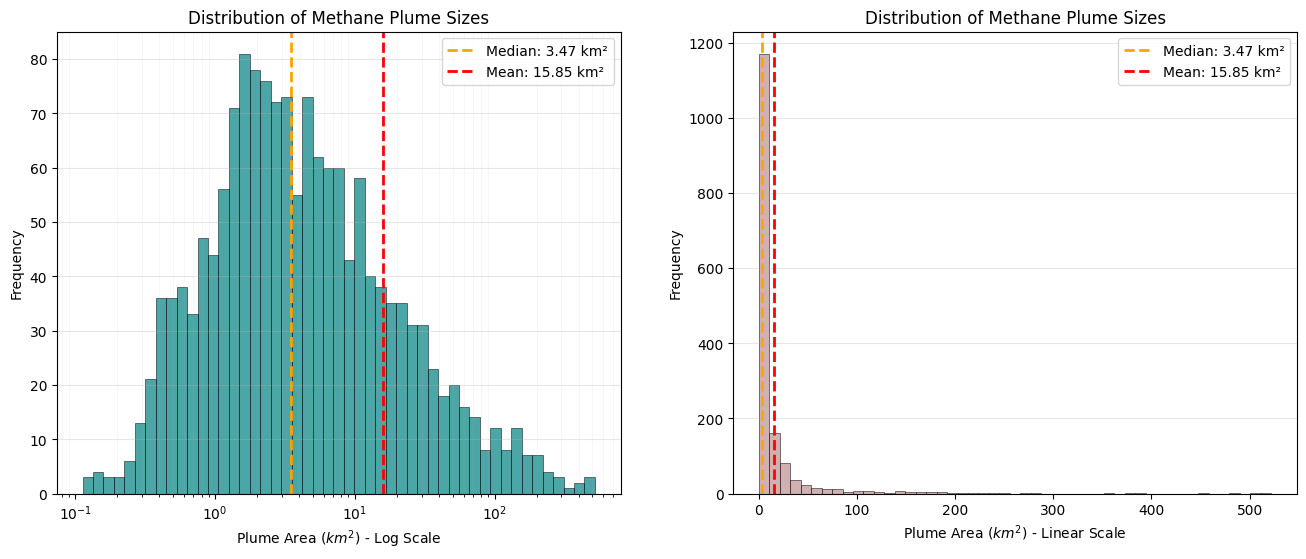

In [6]:
data = gdf[gdf["area_km2"] > 0]["area_km2"]
bins_log = np.logspace(np.log10(data.min()), np.log10(data.max()), 50)
bins_lin = np.linspace(data.min(), data.max(), 50)

# Log scale histogram for plume area
plt.subplots(1, 2, figsize=(16, 6))
plt.subplot(1, 2, 1)
plt.hist(
    data, 
    bins=bins_log, 
    color='teal', 
    edgecolor='black', 
    alpha=0.7,
    linewidth=0.5
)
plt.xscale('log')
plt.axvline(data.median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {data.median():.2f} km²')
plt.axvline(data.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {data.mean():.2f} km²')
plt.xlabel("Plume Area ($km^2$) - Log Scale")
plt.ylabel("Frequency")
plt.title("Distribution of Methane Plume Sizes")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.grid(axis='x', which='minor', alpha=0.1) # Minor grid for log scale

# Linear scale histogram for plume area
plt.subplot(1, 2, 2)
plt.hist(
    data, 
    bins=bins_lin, 
    color='rosybrown', 
    edgecolor='black', 
    alpha=0.7,
    linewidth=0.5
)
plt.axvline(data.median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {data.median():.2f} km²')
plt.axvline(data.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {data.mean():.2f} km²')
plt.xlabel("Plume Area ($km^2$) - Linear Scale")
plt.ylabel("Frequency")
plt.title("Distribution of Methane Plume Sizes")
plt.legend()
plt.grid(axis='y', alpha=0.3)   
plt.grid(axis='x', which='minor', alpha=0.1) # Minor grid for linear scale

plt.show()

In [7]:
print(f"Number of plumes with area > 100 km²: {len(gdf[gdf['area_km2'] > 100])}")
print(f"Number of plumes with area 10-100 km²: {len(gdf[(gdf['area_km2'] > 10) & (gdf['area_km2'] <= 100)])}")
print(f"Number of plumes with area 5-10 km²: {len(gdf[(gdf['area_km2'] > 5) & (gdf['area_km2'] <= 10)])}")
print(f"Number of plumes with area 1-5 km²: {len(gdf[(gdf['area_km2'] > 1) & (gdf['area_km2'] <= 5)])}")    
print(f"Number of plumes with area < 1 km²: {len(gdf[gdf['area_km2'] < 1])}")

Number of plumes with area > 100 km²: 54
Number of plumes with area 10-100 km²: 373
Number of plumes with area 5-10 km²: 224
Number of plumes with area 1-5 km²: 649
Number of plumes with area < 1 km²: 274


In [12]:
irregulars = gdf[(gdf["width_km"] > 25) | (gdf["height_km"] > 25)]

biggest5 = gdf.iloc[[1090, 936, 1001, 1493, 1294]]

print(f"{np.round(irregulars['area_km2'].sum()/gdf['area_km2'].sum() * 100, 2)}% of the total plume area is covered by the 40 biggest plumes.") 
print(f"{np.round(biggest5['area_km2'].sum()/gdf['area_km2'].sum() * 100, 2)}% of the total plume area is covered by the 5 biggest plumes.") #TODO: Discard some parts of the 5 biggest plumes that are not part of the main plume (e.g., the plume in the Gulf of Mexico, which is a combination of several smaller plumes).

32.79% of the total plume area is covered by the 40 biggest plumes.
9.47% of the total plume area is covered by the 5 biggest plumes.


In [ ]:
irregulars.to_csv(WORKING_DIR / "data/irregular_plumes.csv", index=False)

### Further investigation on the biggest plumes

In [14]:
overwater = biggest5.iloc[[3, 4]] # The two plumes that are over water (Gulf of Mexico)
print(f"{np.round(overwater['area_km2'].sum()/gdf['area_km2'].sum() * 100, 2)}% of the total plume area is covered by the huge plumes over water.")

3.41% of the total plume area is covered by the huge plumes over water.


In [15]:
# Checking how many plumes can fit in a 512x512 chip (25 km x 25 km) and a 128x128 chip (7.68 km x 7.68 km) for further cropping and analysis
print(f"Plumes with 512x512 chip: {len(gdf[(gdf["width_km"] < 25) & (gdf["height_km"] < 25)])}")
print(f"Plumes fitting in one 128x128 chip: {len(gdf[(gdf["width_km"] < 7.68) & (gdf["height_km"] < 7.68)])}")
print(f"Plumes fitting in one 128x128 chip (area): {len(gdf[(gdf["area_km2"] < 58.9824)])}")

Plumes with 512x512 chip: 1534
Plumes fitting in one 128x128 chip: 1297
Plumes fitting in one 128x128 chip (area): 1482


## Check the distribution of Plume Concentration

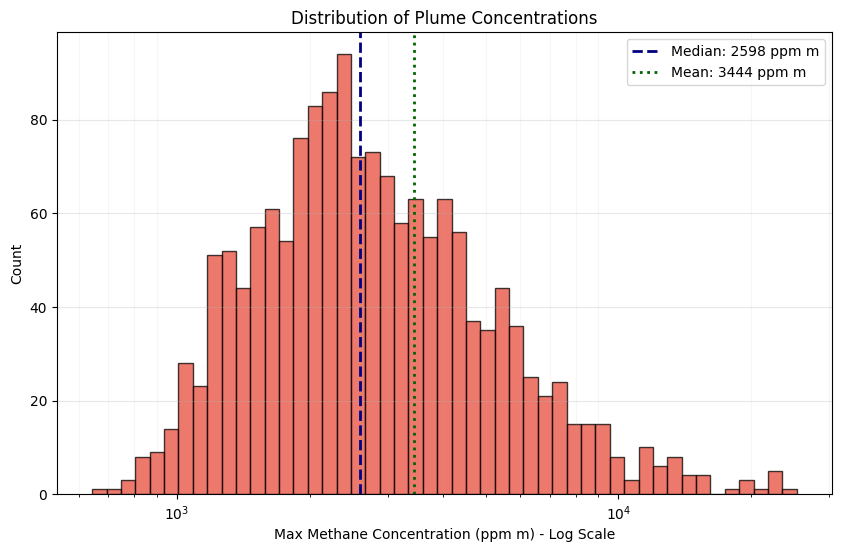

In [16]:
data = gdf[gdf["max_ch4_concentration"] > 0]["max_ch4_concentration"]
bins = np.logspace(np.log10(data.min()), np.log10(data.max()), 50)
plt.figure(figsize=(10, 6))
plt.hist(
    data, 
    bins=bins, 
    color='#e74c3c',  
    edgecolor='black', 
    alpha=0.75
)
plt.xscale('log')
median_val = data.median()
mean_val = data.mean()
plt.axvline(median_val, color='navy', linestyle='--', linewidth=2, label=f'Median: {median_val:.0f} ppm m')
plt.axvline(mean_val, color='darkgreen', linestyle=':', linewidth=2, label=f'Mean: {mean_val:.0f} ppm m')

plt.xlabel("Max Methane Concentration (ppm m) - Log Scale")
plt.ylabel("Count")
plt.title("Distribution of Plume Concentrations")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.grid(axis='x', which='minor', alpha=0.1) # helpful for log scales

plt.show()

## Visualizing the Signal to Noise Ratio

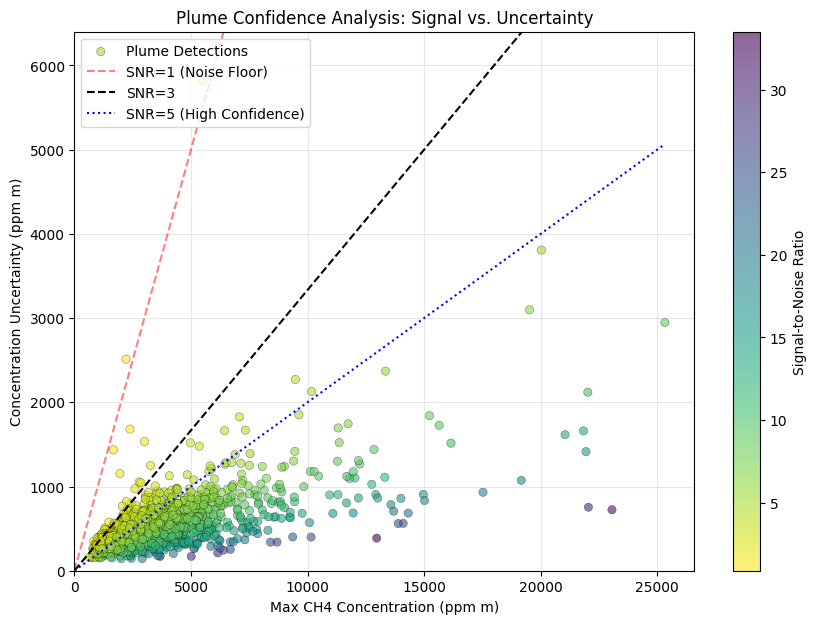

In [17]:
x_range = np.linspace(0, gdf["max_ch4_concentration"].max(), 100)
y_snr1 = x_range / 1
y_snr3 = x_range / 3
y_snr5 = x_range / 5

plt.figure(figsize=(10, 7))
snr_values = gdf["max_ch4_concentration"] / gdf["concentration_uncertainty"]
scatter = plt.scatter(
    gdf["max_ch4_concentration"], 
    gdf["concentration_uncertainty"], 
    c=snr_values, 
    cmap='viridis_r', 
    alpha=0.6, 
    edgecolor='k', 
    linewidth=0.3,
    label='Plume Detections'
)
plt.plot(x_range, y_snr1, 'r--', label='SNR=1 (Noise Floor)', alpha=0.5)
plt.plot(x_range, y_snr3, 'k--', label='SNR=3', linewidth=1.5)
plt.plot(x_range, y_snr5, 'b:', label='SNR=5 (High Confidence)', linewidth=1.5)

plt.colorbar(scatter, label='Signal-to-Noise Ratio')
plt.xlabel("Max CH4 Concentration (ppm m)")
plt.ylabel("Concentration Uncertainty (ppm m)")
plt.title("Plume Confidence Analysis: Signal vs. Uncertainty")
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)

plt.xlim(0, gdf["max_ch4_concentration"].max() * 1.05)
plt.ylim(0, gdf["concentration_uncertainty"].max() * 1.1)

plt.show()

In [18]:
print(f"Number of plumes with SNR < 3: {len(gdf.loc[(gdf["max_ch4_concentration"] / gdf["concentration_uncertainty"]) < 3])}")
gdf = gdf.loc[(gdf["max_ch4_concentration"] / gdf["concentration_uncertainty"]) > 3]

Number of plumes with SNR < 3: 30


## Visualizing the distribution in time

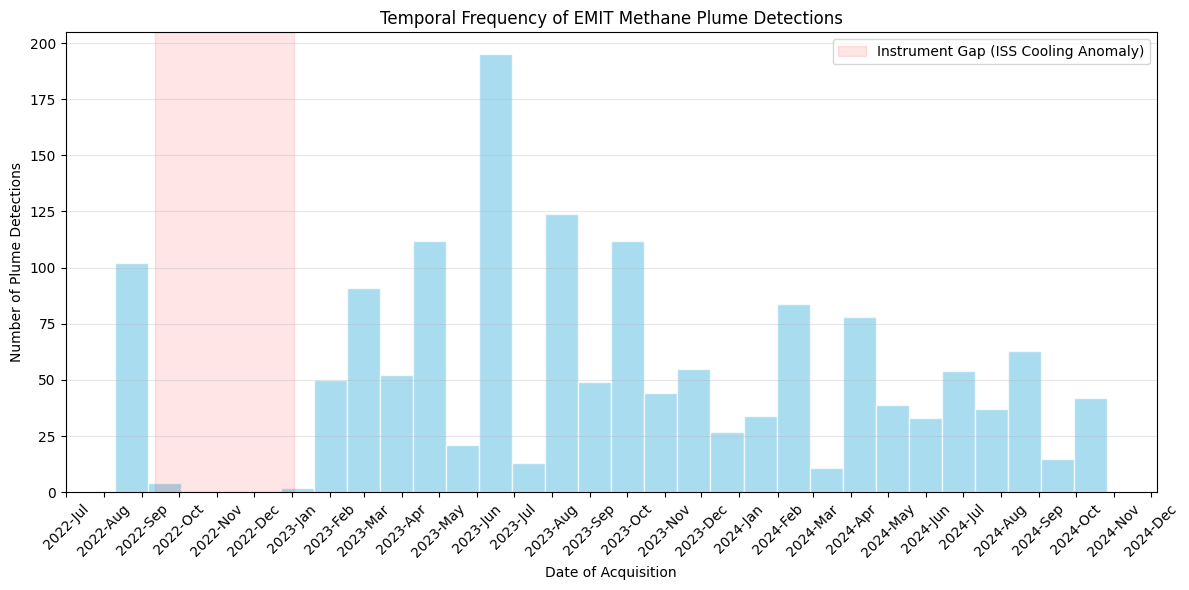

In [20]:
import matplotlib.dates as mdates

gdf["startDate"] = pd.to_datetime(gdf["startDate"], errors='coerce')

fig, ax = plt.subplots(figsize=(12, 6))
counts, bins, patches = ax.hist(
    gdf["startDate"],
    bins=30,
    color='skyblue',
    edgecolor='white',
    alpha=0.7
)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%b'))

plt.xticks(rotation=45)
plt.xlabel("Date of Acquisition")
plt.ylabel("Number of Plume Detections")
plt.title("Temporal Frequency of EMIT Methane Plume Detections")
plt.grid(axis='y', alpha=0.3)

ax.axvspan(pd.to_datetime('2022-09-12'), pd.to_datetime('2023-01-03'), color='red', alpha=0.1, label='Instrument Gap (ISS Cooling Anomaly)')
ax.legend()

plt.tight_layout()
plt.show()

## Visualize the geographical distribution

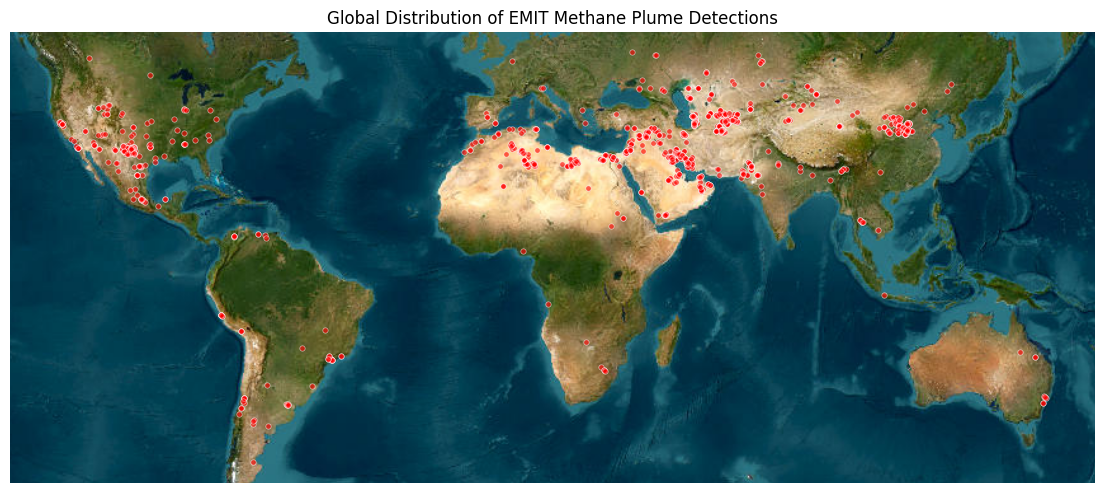

In [21]:
import geopandas as gpd
import contextily as ctx
gdf_points = gpd.GeoDataFrame(
     gdf, 
     geometry=gpd.points_from_xy(gdf["longitude (centroid)"], gdf["latitude (centroid)"]),
     crs="EPSG:4326"  
 )

gdf_web = gdf_points.to_crs(epsg=3857)
fig, ax = plt.subplots(figsize=(14, 10))
gdf_web.plot(
    ax=ax, 
    markersize=15, 
    color='red', 
    alpha=0.6, 
    edgecolor='white', 
    linewidth=0.5
)
ctx.add_basemap(ax, source=ctx.providers.Esri.WorldImagery, attribution=False)

ax.set_axis_off()
plt.title("Global Distribution of EMIT Methane Plume Detections")
plt.show()

In [ ]:
import folium

gdf = gpd.GeoDataFrame(gdf, geometry='geometry', crs="EPSG:4326")
#gdf = gpd.GeoDataFrame(biggest5, geometry='geometry', crs="EPSG:4326") # --> show only the biggest 5

m = gdf.explore(
    column="max_ch4_concentration",
    cmap="plasma",
    tiles="CartoDB positron",
    style_kwds={"weight": 2, "fillOpacity": 0.4},
    tooltip=[
        "name", 
        "startDate", 
        "max_ch4_concentration", 
        "area_km2"
    ],
    popup=True
)

folium.LayerControl().add_to(m)
m.add_child(folium.LatLngPopup())
m

## EarthAccess download test (NOT USED)

In [10]:
earthaccess.login(persist=True)

In [11]:
Query = earthaccess.collection_query().keyword('emit')
print(f'Collections found: {Query.hits()}')

Collections found: 65


In [12]:
collections = Query.fields(['ShortName']).get()

In [13]:
short_names = [product['short-name'] for product in [collection.summary() for collection in collections]]

In [14]:
EMIT_L2B_CH4 = 'EMITL2BCH4PLM'
EMIT_L2A_RFL = 'EMITL2ARFL'
EMIT_L1B_RAD = 'EMITL1BRAD'

In [15]:
plume_results = earthaccess.search_data(short_name=EMIT_L2B_CH4)
plume = plume_results[0]

In [16]:
date_format = '%Y-%m-%dT%H:%M:%SZ'
start_date = datetime.strptime(plume['umm']['TemporalExtent']['SingleDateTime'], date_format)
start_date = start_date.replace(hour=0, minute=0, second=0, microsecond=0)
end_date = start_date + timedelta(days=1)
start_date = start_date.strftime(date_format)
end_date = end_date.strftime(date_format)

In [27]:
points = plume['umm']['SpatialExtent']['HorizontalSpatialDomain']['Geometry']['GPolygons'][0]['Boundary']['Points']
polygon = gpd.GeoSeries(Polygon([(p['Longitude'], p['Latitude']) for p in points]))

rep = polygon.representative_point()[0]

scene_id = plume['umm']['AdditionalAttributes'][5]['Values'][0][-5:-2]

In [28]:
plume['umm']['AdditionalAttributes'][5]


{'Name': 'SOURCE_SCENES',
 'Values': ["['EMIT_L2B_CH4ENH_V002_20220810T064957_2222205_033']"]}

In [29]:
start_date, end_date

('2022-08-10T00:00:00Z', '2022-08-11T00:00:00Z')

In [30]:
query_res = earthaccess.search_data(short_name=EMIT_L2A_RFL,
                                    point=(rep.x, rep.y),
                                    temporal=(start_date[:10], end_date[:10]))

In [32]:
scene_ids = [q['meta']['native-id'][-3:] for q in query_res]
idx = scene_ids.index(scene_id)
scene_ids

['033', '957']

In [33]:
plume

Collection: {'ShortName': 'EMITL2BCH4PLM', 'Version': '002'}
Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Longitude': 35.19766, 'Latitude': 31.13575}, {'Longitude': 35.19766, 'Latitude': 31.13521}, {'Longitude': 35.19549, 'Latitude': 31.13521}, {'Longitude': 35.19549, 'Latitude': 31.13467}, {'Longitude': 35.19441, 'Latitude': 31.13413}, {'Longitude': 35.19441, 'Latitude': 31.13358}, {'Longitude': 35.19333, 'Latitude': 31.13304}, {'Longitude': 35.19333, 'Latitude': 31.13196}, {'Longitude': 35.19278, 'Latitude': 31.13196}, {'Longitude': 35.19278, 'Latitude': 31.13033}, {'Longitude': 35.19224, 'Latitude': 31.13033}, {'Longitude': 35.19224, 'Latitude': 31.12274}, {'Longitude': 35.19278, 'Latitude': 31.12274}, {'Longitude': 35.19278, 'Latitude': 31.12111}, {'Longitude': 35.19333, 'Latitude': 31.12111}, {'Longitude': 35.19333, 'Latitude': 31.12003}, {'Longitude': 35.19387, 'Latitude': 31.12003}, {'Longitude': 35.19441, 'Latitude': 31.11677}, {'Longitude': 35.19549, 'Latitude': 31.11623}, {'Longitude': 35.19604, 'Latitude': 31.11515}, {'Longitude': 35.19658, 'Latitude': 31.11515}, {'Longitude': 35.19712, 'Latitude': 31.11406}, {'Longitude': 35.19766, 'Latitude': 31.11406}, {'Longitude': 35.19821, 'Latitude': 31.11298}, {'Longitude': 35.19929, 'Latitude': 31.11298}, {'Longitude': 35.19929, 'Latitude': 31.11244}, {'Longitude': 35.20037, 'Latitude': 31.11244}, {'Longitude': 35.20037, 'Latitude': 31.11189}, {'Longitude': 35.20254, 'Latitude': 31.11189}, {'Longitude': 35.20254, 'Latitude': 31.11135}, {'Longitude': 35.2123, 'Latitude': 31.11135}, {'Longitude': 35.2123, 'Latitude': 31.11189}, {'Longitude': 35.21447, 'Latitude': 31.11189}, {'Longitude': 35.21447, 'Latitude': 31.11244}, {'Longitude': 35.2161, 'Latitude': 31.11244}, {'Longitude': 35.2161, 'Latitude': 31.11298}, {'Longitude': 35.21718, 'Latitude': 31.11298}, {'Longitude': 35.21718, 'Latitude': 31.11352}, {'Longitude': 35.21827, 'Latitude': 31.11352}, {'Longitude': 35.21827, 'Latitude': 31.11406}, {'Longitude': 35.21935, 'Latitude': 31.11406}, {'Longitude': 35.21935, 'Latitude': 31.1146}, {'Longitude': 35.21989, 'Latitude': 31.1146}, {'Longitude': 35.21989, 'Latitude': 31.11515}, {'Longitude': 35.22098, 'Latitude': 31.11569}, {'Longitude': 35.22098, 'Latitude': 31.11623}, {'Longitude': 35.22152, 'Latitude': 31.11623}, {'Longitude': 35.22152, 'Latitude': 31.11786}, {'Longitude': 35.22206, 'Latitude': 31.11786}, {'Longitude': 35.22206, 'Latitude': 31.11894}, {'Longitude': 35.22261, 'Latitude': 31.11894}, {'Longitude': 35.22261, 'Latitude': 31.12165}, {'Longitude': 35.22206, 'Latitude': 31.12165}, {'Longitude': 35.22206, 'Latitude': 31.12653}, {'Longitude': 35.22152, 'Latitude': 31.12653}, {'Longitude': 35.22152, 'Latitude': 31.12816}, {'Longitude': 35.22098, 'Latitude': 31.12816}, {'Longitude': 35.22098, 'Latitude': 31.12925}, {'Longitude': 35.22044, 'Latitude': 31.12925}, {'Longitude': 35.21989, 'Latitude': 31.13033}, {'Longitude': 35.21935, 'Latitude': 31.13033}, {'Longitude': 35.21935, 'Latitude': 31.13087}, {'Longitude': 35.21827, 'Latitude': 31.13087}, {'Longitude': 35.21827, 'Latitude': 31.13141}, {'Longitude': 35.21718, 'Latitude': 31.13141}, {'Longitude': 35.21718, 'Latitude': 31.13196}, {'Longitude': 35.21556, 'Latitude': 31.13196}, {'Longitude': 35.21556, 'Latitude': 31.1325}, {'Longitude': 35.21339, 'Latitude': 31.1325}, {'Longitude': 35.21339, 'Latitude': 31.13304}, {'Longitude': 35.2058, 'Latitude': 31.13304}, {'Longitude': 35.2058, 'Latitude': 31.13358}, {'Longitude': 35.20471, 'Latitude': 31.13413}, {'Longitude': 35.20471, 'Latitude': 31.13467}, {'Longitude': 35.20417, 'Latitude': 31.13467}, {'Longitude': 35.20417, 'Latitude': 31.13521}, {'Longitude': 35.20309, 'Latitude': 31.13521}, {'Longitude': 35.20309, 'Latitude': 31.13575}, {'Longitude': 35.19766, 'Latitude': 31.13575}]}}]}}}
Temporal coverage: {'SingleDateTime': '2022-08-10T06:49:57Z'}
Size(MB): 0.04396247863769531
Data: ['https://data.lpdaac.earthdatacl

In [34]:
len(scene_ids)

2

In [35]:
emit_og_img = query_res[idx]
emit_og_img['umm']

{'TemporalExtent': {'RangeDateTime': {'BeginningDateTime': '2022-08-10T06:49:57Z',
   'EndingDateTime': '2022-08-10T06:50:09Z'}},
 'GranuleUR': 'EMIT_L2A_RFL_001_20220810T064957_2222205_033',
 'AdditionalAttributes': [{'Name': 'SOFTWARE_BUILD_VERSION',
   'Values': ['010609']},
  {'Name': 'Identifier_product_doi_authority', 'Values': ['https://doi.org']},
  {'Name': 'Identifier_product_doi',
   'Values': ['10.5067/EMIT/EMITL2ARFL.001']},
  {'Name': 'ORBIT', 'Values': ['2222205']},
  {'Name': 'ORBIT_SEGMENT', 'Values': ['1']},
  {'Name': 'SCENE', 'Values': ['33']},
  {'Name': 'SOLAR_ZENITH', 'Values': ['8.84']},
  {'Name': 'SOLAR_AZIMUTH', 'Values': ['53.37']}],
 'SpatialExtent': {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Longitude': 35.504478454589844,
         'Latitude': 31.59307098388672},
        {'Longitude': 34.803245544433594, 'Latitude': 30.961956024169922},
        {'Longitude': 35.330726623535156, 'Latitude': 30.375873565673828},
      

In [36]:
plume['Image_URL'] = query_res[idx]["umm"]["RelatedUrls"]